# Детекция автотранспорта — обучение YOLOv8 (n / s / m)

Выпускной проект DLS, продуктовый трек. Задача: детекция автотранспорта и других участников
дорожного движения на кадрах с дронов (10 классов: пешеход, человек, велосипед, машина,
фургон, грузовик, рикша, рикша с навесом, автобус, мотоцикл) на датасете
[VisDrone2019-DET](https://www.kaggle.com/datasets/kushagrapandya/visdrone-dataset)
(Tianjin University, 10209 изображений, готовая разбивка train/val/test).

В этом ноутбуке:
1. Загрузка датасета с Kaggle через `kagglehub`.
2. Конвертация разметки VisDrone → YOLO.
3. Обучение трёх моделей: **YOLOv8n**, **YOLOv8s**, **YOLOv8m**.
4. Сравнение метрик (mAP@0.5, mAP@0.5:0.95, скорость обучения/инференса).
5. Экспорт весов и загрузка на Hugging Face Hub для использования в веб-приложении.

**Важно:** для скачивания датасета нужен Kaggle API-токен — создайте его на
[kaggle.com/settings](https://www.kaggle.com/settings) (API → Create New Token) и загрузите
`kaggle.json` в ячейке ниже.

## 1. Установка зависимостей и авторизация Kaggle

In [67]:
!pip install -q ultralytics==8.3.63 kagglehub huggingface_hub

In [68]:
from google.colab import files
import os

# Загрузите kaggle.json, скачанный с https://www.kaggle.com/settings
os.makedirs("/root/.kaggle", exist_ok=True)
uploaded = files.upload()  # выберите kaggle.json
for fname in uploaded:
    os.rename(fname, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

Saving kaggle.json to kaggle.json


## 2. Загрузка датасета VisDrone2019-DET

In [69]:
import kagglehub

DATASET_ROOT = kagglehub.dataset_download("kushagrapandya/visdrone-dataset")
print("Датасет скачан в:", DATASET_ROOT)
print("Содержимое:", os.listdir(DATASET_ROOT))

Using Colab cache for faster access to the 'visdrone-dataset' dataset.
Датасет скачан в: /kaggle/input/visdrone-dataset
Содержимое: ['VisDrone2019-DET-test-challenge', 'VisDrone2019-DET-test-dev', 'VisDrone2019-DET-train', 'VisDrone.yaml', 'VisDrone2019-DET-val']


## 3. Конвертация разметки VisDrone → YOLO

Формат аннотаций VisDrone — построчный `.txt` для каждого изображения:
`x, y, w, h, score, category, truncation, occlusion` в абсолютных пиксельных координатах.
Категория `0` — служебный класс "ignored regions", исключаем его. Остальные категории
(`1`..`10`) сдвигаем на единицу, чтобы получить YOLO-индексы `0`..`9`.

In [70]:
CLASS_NAMES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor",
]


SPLIT_DIRS = {
    "train": "VisDrone2019-DET-train/VisDrone2019-DET-train",
    "val": "VisDrone2019-DET-val/VisDrone2019-DET-val",
    "test": "VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev",
}

for split, dirname in SPLIT_DIRS.items():
    split_path = os.path.join(DATASET_ROOT, dirname)
    assert os.path.isdir(split_path), f"Не найдена папка: {split_path}"
    n_images = len(os.listdir(os.path.join(split_path, "images")))
    print(f"{split}: {n_images} изображений ({split_path})")

train: 6471 изображений (/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train)
val: 548 изображений (/kaggle/input/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val)
test: 1610 изображений (/kaggle/input/visdrone-dataset/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev)


In [71]:
from pathlib import Path
from PIL import Image
from tqdm import tqdm


YOLO_DATASET_ROOT = Path("/content/yolo_dataset")


def convert_box(size, box):
    # Перевод VisDrone bbox (x, y, w, h абсолютные) в YOLO xywh (нормализованные, центр)
    dw, dh = 1.0 / size[0], 1.0 / size[1]
    x, y, w, h = box
    return (x + w / 2) * dw, (y + h / 2) * dh, w * dw, h * dh


def visdrone_to_yolo(split: str, src_dir: Path):
    dst_dir = YOLO_DATASET_ROOT / split
    dst_dir.mkdir(parents=True, exist_ok=True)

    images_link = dst_dir / "images"
    if not images_link.exists():
        images_link.symlink_to(src_dir / "images")

    labels_dir = dst_dir / "labels"
    labels_dir.mkdir(parents=True, exist_ok=True)

    ann_files = list((src_dir / "annotations").glob("*.txt"))
    for ann_path in tqdm(ann_files, desc=f"Конвертация {split}"):
        img_path = (src_dir / "images" / ann_path.name).with_suffix(".jpg")
        img_size = Image.open(img_path).size

        lines = []
        with open(ann_path) as f:
            for row in f.read().strip().splitlines():
                parts = row.split(",")
                if parts[4] == "0":  # score=0 -> ignored region, пропускаем
                    continue
                cls_idx = int(parts[5]) - 1  # VisDrone категории 1..10 -> YOLO 0..9
                if not (0 <= cls_idx < len(CLASS_NAMES)):
                    continue
                box = convert_box(img_size, tuple(map(int, parts[:4])))
                lines.append(f"{cls_idx} " + " ".join(f"{v:.6f}" for v in box))

        with open(labels_dir / ann_path.with_suffix(".txt").name, "w") as f:
            f.write("\n".join(lines))


for split, dirname in SPLIT_DIRS.items():
    visdrone_to_yolo(split, Path(DATASET_ROOT) / dirname)

Конвертация test: 100%|██████████| 1610/1610 [00:04<00:00, 384.82it/s]


In [72]:
dataset_yaml = f"""path: {YOLO_DATASET_ROOT}
train: train
val: val
test: test

names:
{chr(10).join(f'  {idx}: {name}' for idx, name in enumerate(CLASS_NAMES))}
"""

DATASET_YAML_PATH = "/content/vehicle_detection.yaml"
with open(DATASET_YAML_PATH, "w", encoding="utf-8") as f:
    f.write(dataset_yaml)

print(dataset_yaml)

path: /content/yolo_dataset
train: train
val: val
test: test

names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



## 4. Обучение моделей

Обучаем три модели одного семейства YOLOv8 разного размера — **n** (nano), **s** (small),
**m** (medium). Даём пользователю в приложении выбор между быстрой/лёгкой и точной/медленной
моделью.

In [73]:
from ultralytics import YOLO
import time

EPOCHS = 60
IMG_SIZE = 640
RUNS = {}

### 4.1 YOLOv8n

In [74]:
model_n = YOLO("yolov8n.pt")
start = time.time()
results_n = model_n.train(
    data=DATASET_YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=16,
    name="yolov8n_vehicle_detection",
    patience=15,
    exist_ok=True,
)
RUNS["yolov8n"] = {"train_time_sec": time.time() - start, "model": model_n}

New https://pypi.org/project/ultralytics/8.4.92 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/vehicle_detection.yaml, epochs=60, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8n_vehicle_detection, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False,

100%|██████████| 5.35M/5.35M [00:00<00:00, 191MB/s]


AMP: checks passed ✅


train: Scanning /content/yolo_dataset/train/labels.cache... 6471 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6471/6471 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/yolo_dataset/train/images/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/9999987_00000_d_0000049.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      60/60      9.09G       1.31     0.9043     0.9054        470        640: 100%|██████████| 405/405 [00:41<00:00,  9.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:03<00:00,  5.38it/s]

                   all        548      38759      0.444      0.315      0.318      0.184



60 epochs completed in 0.791 hours.
Optimizer stripped from runs/detect/yolov8n_vehicle_detection/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolov8n_vehicle_detection/weights/best.pt, 6.2MB

Validating runs/detect/yolov8n_vehicle_detection/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 168 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:10<00:00,  1.75it/s]


                   all        548      38759      0.437      0.322      0.322      0.186
            pedestrian        520       8844      0.428      0.326      0.326      0.138
                people        482       5125      0.469      0.227      0.254     0.0934
               bicycle        364       1287      0.234     0.0971     0.0785     0.0316
                   car        515      14064      0.622      0.735       0.74      0.502
                   van        421       1975       0.44      0.366      0.361      0.247
                 truck        266        750      0.483      0.299      0.302      0.197
              tricycle        337       1045      0.404      0.247      0.233      0.121
       awning-tricycle        220        532      0.313      0.147      0.136     0.0884
                   bus        131        251      0.535      0.418      0.441        0.3
                 motor        485       4886      0.444      0.358      0.345      0.139
Speed: 0.1ms preproce

### 4.2 YOLOv8s

In [75]:
model_s = YOLO("yolov8s.pt")
start = time.time()
results_s = model_s.train(
    data=DATASET_YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=16,
    name="yolov8s_vehicle_detection",
    patience=15,
    exist_ok=True,
)
RUNS["yolov8s"] = {"train_time_sec": time.time() - start, "model": model_s}

New https://pypi.org/project/ultralytics/8.4.92 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/vehicle_detection.yaml, epochs=60, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8s_vehicle_detection, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False,

train: Scanning /content/yolo_dataset/train/labels.cache... 6471 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6471/6471 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/yolo_dataset/train/images/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/9999987_00000_d_0000049.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/yolo_dataset/val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]


Plotting labels to runs/detect/yolov8s_vehicle_detection/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/yolov8s_vehicle_detection
Starting training for 60 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      60/60      10.7G      1.138     0.6975     0.8718        470        640: 100%|██████████| 405/405 [00:42<00:00,  9.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:03<00:00,  5.55it/s]

                   all        548      38759      0.509      0.382      0.396      0.234



60 epochs completed in 0.804 hours.
Optimizer stripped from runs/detect/yolov8s_vehicle_detection/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/yolov8s_vehicle_detection/weights/best.pt, 22.5MB

Validating runs/detect/yolov8s_vehicle_detection/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 168 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:10<00:00,  1.65it/s]


                   all        548      38759      0.514      0.379      0.397      0.236
            pedestrian        520       8844       0.54      0.386      0.421      0.192
                people        482       5125       0.59      0.269      0.334      0.126
               bicycle        364       1287       0.28      0.183      0.143     0.0602
                   car        515      14064       0.73      0.763       0.79      0.558
                   van        421       1975      0.485      0.453      0.445      0.314
                 truck        266        750      0.529      0.367      0.372      0.253
              tricycle        337       1045      0.406      0.291      0.282      0.159
       awning-tricycle        220        532      0.355       0.16      0.172      0.104
                   bus        131        251      0.676      0.499      0.574      0.404
                 motor        485       4886      0.548      0.424      0.439       0.19
Speed: 0.1ms preproce

### 4.3 YOLOv8m

In [76]:
model_m = YOLO("yolov8m.pt")
start = time.time()
results_m = model_m.train(
    data=DATASET_YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=8,
    name="yolov8m_vehicle_detection",
    patience=15,
    exist_ok=True,
)
RUNS["yolov8m"] = {"train_time_sec": time.time() - start, "model": model_m}

New https://pypi.org/project/ultralytics/8.4.92 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/vehicle_detection.yaml, epochs=60, time=None, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8m_vehicle_detection, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, 

train: Scanning /content/yolo_dataset/train/labels.cache... 6471 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6471/6471 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/yolo_dataset/train/images/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/yolo_dataset/train/images/9999987_00000_d_0000049.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/yolo_dataset/val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]


Plotting labels to runs/detect/yolov8m_vehicle_detection/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/yolov8m_vehicle_detection
Starting training for 60 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      60/60      7.79G      1.059      0.611     0.8664        470        640: 100%|██████████| 809/809 [01:20<00:00, 10.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:03<00:00,  8.83it/s]


                   all        548      38759      0.544       0.42      0.435      0.264

60 epochs completed in 1.466 hours.
Optimizer stripped from runs/detect/yolov8m_vehicle_detection/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/yolov8m_vehicle_detection/weights/best.pt, 52.0MB

Validating runs/detect/yolov8m_vehicle_detection/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 218 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:11<00:00,  3.13it/s]


                   all        548      38759      0.523      0.433      0.442      0.268
            pedestrian        520       8844      0.565      0.443      0.477      0.225
                people        482       5125      0.601      0.321      0.377      0.154
               bicycle        364       1287      0.268      0.215      0.177     0.0804
                   car        515      14064      0.757      0.788      0.818      0.591
                   van        421       1975      0.518      0.501      0.489      0.349
                 truck        266        750      0.511      0.431       0.43      0.284
              tricycle        337       1045      0.455      0.365      0.346      0.197
       awning-tricycle        220        532      0.309      0.201      0.179      0.111
                   bus        131        251        0.7      0.567      0.624      0.458
                 motor        485       4886      0.545      0.497      0.497      0.232
Speed: 0.1ms preproce

## 5. Оценка на тестовой выборке и сравнение метрик

In [77]:
metrics_summary = {}

for model_id in ("yolov8n", "yolov8s", "yolov8m"):
    model = RUNS[model_id]["model"]
    val_results = model.val(data=DATASET_YAML_PATH, split="test", imgsz=IMG_SIZE)
    metrics_summary[model_id] = {
        "mAP50": float(val_results.box.map50),
        "mAP50-95": float(val_results.box.map),
        "precision": float(val_results.box.mp),
        "recall": float(val_results.box.mr),
        "train_time_sec": RUNS[model_id]["train_time_sec"],
    }

import pandas as pd
metrics_df = pd.DataFrame(metrics_summary).T
metrics_df

Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 168 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/yolo_dataset/test/labels.cache... 1610 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1610/1610 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 101/101 [00:21<00:00,  4.79it/s]


                   all       1610      75102       0.37      0.284      0.261      0.148
            pedestrian       1197      21006      0.403      0.212      0.211     0.0816
                people        797       6376      0.407     0.0838      0.109     0.0369
               bicycle        377       1302      0.177     0.0561     0.0513     0.0195
                   car       1530      28074      0.573       0.68      0.658      0.404
                   van       1168       5771      0.331      0.352      0.297      0.189
                 truck        750       2659      0.349      0.356      0.308       0.19
              tricycle        245        530      0.208      0.203      0.133       0.07
       awning-tricycle        233        599      0.333       0.15      0.139     0.0742
                   bus        838       2940      0.588      0.491      0.501       0.34
                 motor        794       5845      0.331      0.257      0.206     0.0765
Speed: 0.1ms preproce

val: Scanning /content/yolo_dataset/test/labels.cache... 1610 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1610/1610 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 101/101 [00:22<00:00,  4.56it/s]


                   all       1610      75102      0.436      0.336      0.319      0.187
            pedestrian       1197      21006      0.487      0.257       0.27      0.109
                people        797       6376      0.466      0.109      0.142     0.0473
               bicycle        377       1302       0.22      0.114     0.0893     0.0382
                   car       1530      28074       0.66      0.715      0.714      0.459
                   van       1168       5771      0.414      0.395      0.363      0.242
                 truck        750       2659      0.395      0.431      0.386       0.25
              tricycle        245        530      0.242      0.294      0.185     0.0994
       awning-tricycle        233        599      0.379      0.187      0.185      0.103
                   bus        838       2940      0.676      0.536      0.574      0.407
                 motor        794       5845      0.417      0.324      0.279      0.111
Speed: 0.1ms preproce

val: Scanning /content/yolo_dataset/test/labels.cache... 1610 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1610/1610 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:21<00:00,  9.40it/s]


                   all       1610      75102      0.492      0.373       0.36      0.214
            pedestrian       1197      21006      0.552      0.278      0.305      0.127
                people        797       6376      0.519       0.12      0.165     0.0594
               bicycle        377       1302      0.261      0.163      0.123     0.0512
                   car       1530      28074      0.729      0.737      0.751      0.492
                   van       1168       5771      0.487      0.428      0.417      0.282
                 truck        750       2659      0.482      0.498      0.468      0.313
              tricycle        245        530      0.296      0.347      0.208      0.113
       awning-tricycle        233        599      0.402      0.247      0.225      0.131
                   bus        838       2940      0.727      0.547      0.606      0.437
                 motor        794       5845       0.47      0.366      0.331      0.137
Speed: 0.1ms preproce

,mAP50,mAP50-95,precision,recall,train_time_sec
yolov8n,0.261311,0.148087,0.370073,0.284192,2873.662126
yolov8s,0.318731,0.186514,0.435621,0.336236,2922.771679
yolov8m,0.359876,0.214453,0.492392,0.373084,5307.037150


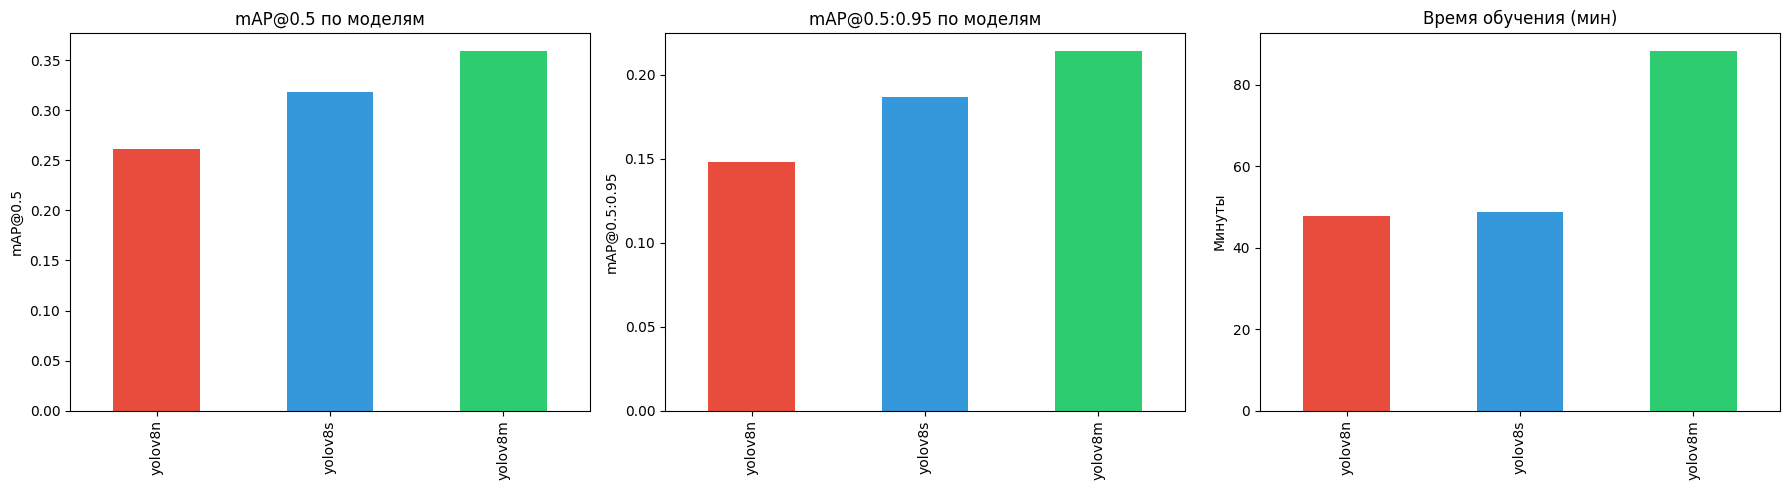

In [78]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_df["mAP50"].plot(kind="bar", ax=axes[0], color=["#e74c3c", "#3498db", "#2ecc71"])
axes[0].set_title("mAP@0.5 по моделям")
axes[0].set_ylabel("mAP@0.5")

metrics_df["mAP50-95"].plot(kind="bar", ax=axes[1], color=["#e74c3c", "#3498db", "#2ecc71"])
axes[1].set_title("mAP@0.5:0.95 по моделям")
axes[1].set_ylabel("mAP@0.5:0.95")

(metrics_df["train_time_sec"] / 60).plot(kind="bar", ax=axes[2], color=["#e74c3c", "#3498db", "#2ecc71"])
axes[2].set_title("Время обучения (мин)")
axes[2].set_ylabel("Минуты")

plt.tight_layout()
plt.savefig("/content/metrics_comparison.png", dpi=150)
plt.show()

### Кривые обучения

Ultralytics сам сохраняет `results.png` (loss/mAP по эпохам) в папку `runs/detect/<name>/`
для каждого запуска. Отобразим их рядом для сравнения скорости сходимости.

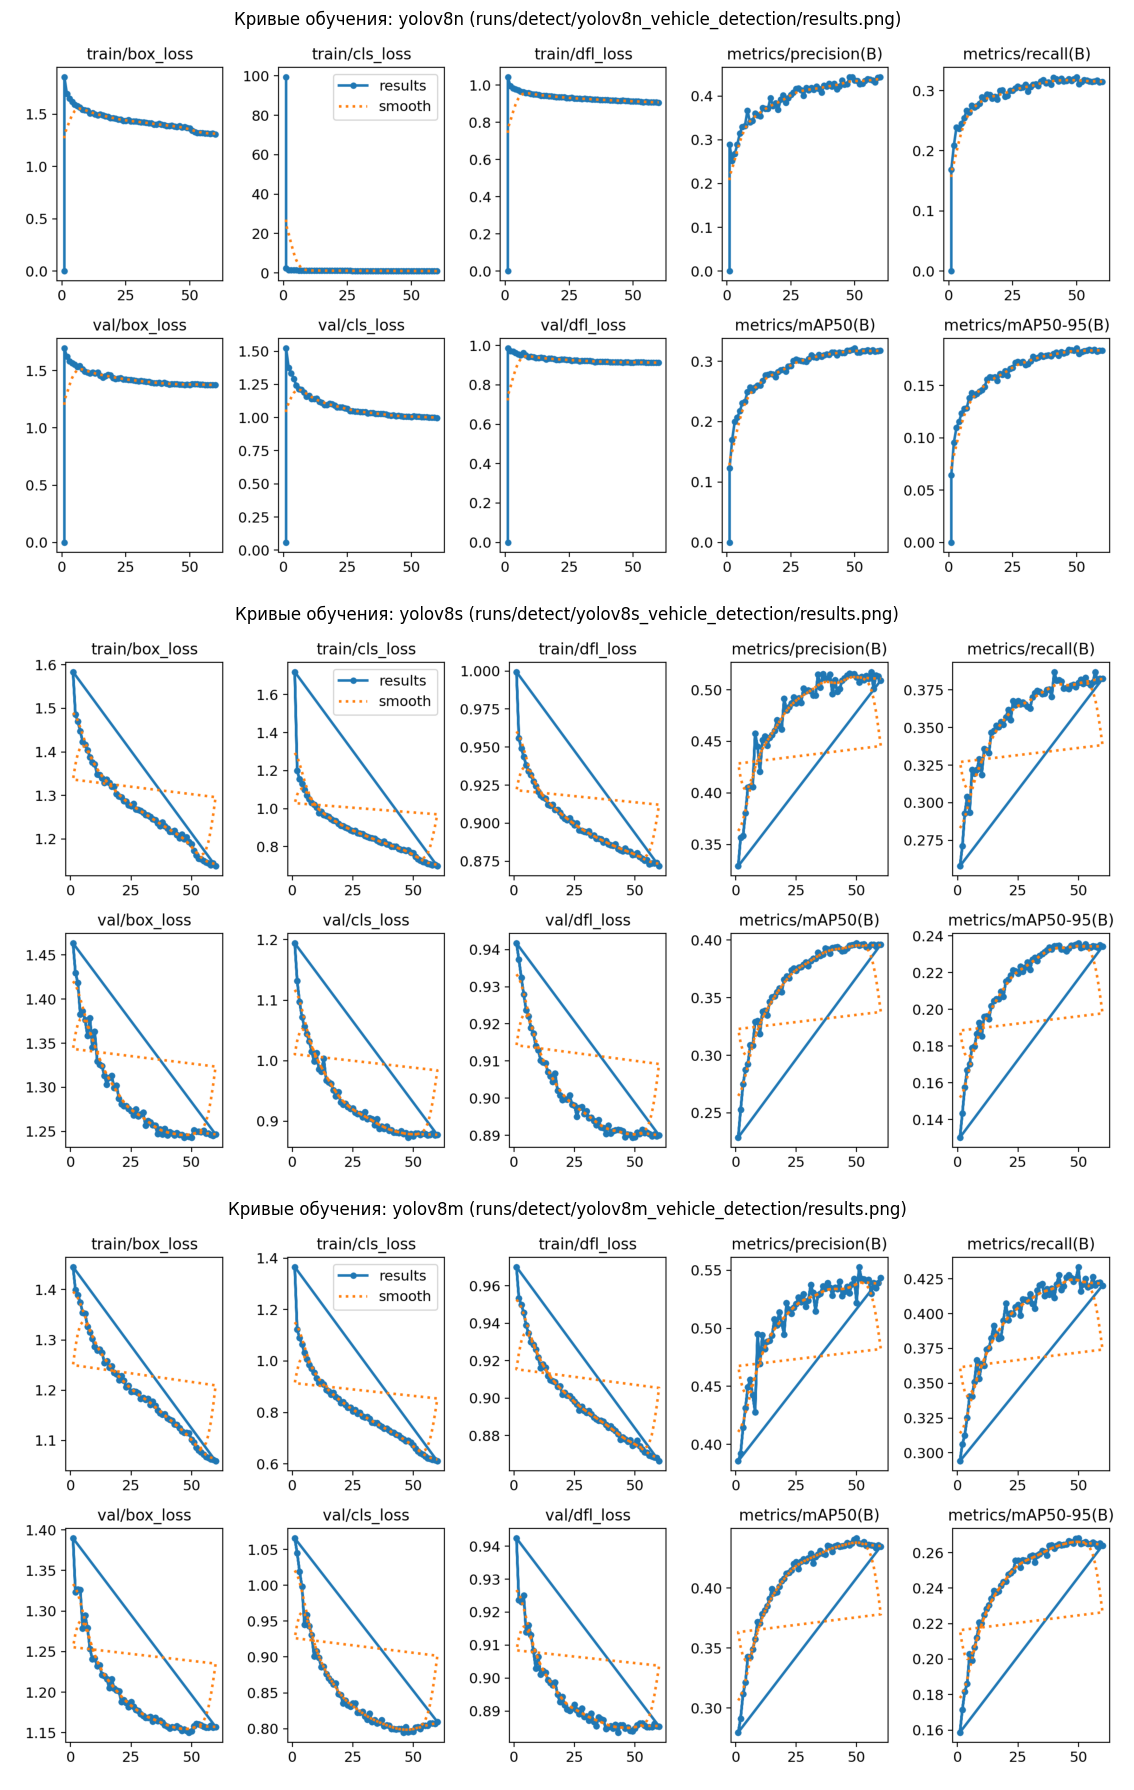

In [79]:
from PIL import Image as PILImage
import glob


def find_results_png(model_id: str) -> str | None:

    matches = glob.glob(f"runs/detect/{model_id}_vehicle_detection*/results.png")
    return max(matches, key=os.path.getmtime) if matches else None


fig, axes = plt.subplots(3, 1, figsize=(14, 18))
for ax, model_id in zip(axes, ("yolov8n", "yolov8s", "yolov8m")):
    results_png = find_results_png(model_id)
    if results_png:
        ax.imshow(PILImage.open(results_png))
        ax.set_title(f"Кривые обучения: {model_id} ({results_png})")
    else:
        ax.set_title(f"Кривые обучения: {model_id} — results.png не найден")
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/training_curves_all.png", dpi=150)
plt.show()

## 6. Анализ результатов и гипотезы

Заполните после просмотра метрик и графиков (пример структуры анализа):

- **Какая модель быстрее обучилась?** Сравните `train_time_sec` — обычно YOLOv8n быстрее
  всего благодаря меньшему числу параметров, YOLOv8m — медленнее.
- **Какая модель точнее (mAP@0.5)?** Обычно YOLOv8m > YOLOv8s > YOLOv8n за счёт большей
  ёмкости модели, но прирост точности может быть непропорционален приросту времени обучения
  и инференса.
- **Гипотезы по возможным проблемам:**
  - Сильный дисбаланс классов (`car` — самый частый класс, `awning-tricycle` и `tricycle` —
    редкие) может приводить к низкому recall на редких классах.
  - Мелкие объекты на аэрофото (пешеходы, велосипеды с большой высоты съёмки) сложнее
    детектировать — типичная проблема VisDrone из-за высокого разрешения кадров и малого
    относительного размера объектов.
  - Похожие по силуэту классы (`car` vs `van`, `truck` vs `bus`, `tricycle` vs
    `awning-tricycle`) могут путаться между собой — видно по confusion matrix
    (`runs/detect/<name>/confusion_matrix.png`).
  - Загущённые сцены (много мелких объектов рядом) — модель может пропускать перекрывающиеся
    объекты (низкий recall при высокой occlusion).
- **Как улучшить:**
  - Увеличение разрешения (`imgsz`) для лучшей детекции мелких объектов.
  - Аугментации, ориентированные на редкие классы (oversampling `tricycle`, `awning-tricycle`).
  - Tiled inference / slicing (например, SAHI) для аэрофото с мелкими объектами.
  - Больше эпох / learning rate scheduling, если кривые обучения ещё не вышли на плато.

## 7. Экспорт весов и загрузка на Hugging Face Hub

In [80]:
import shutil

MODELS_EXPORT_DIR = "/content/exported_models"
os.makedirs(MODELS_EXPORT_DIR, exist_ok=True)

weight_files = {
    "yolov8n": "runs/detect/yolov8n_vehicle_detection/weights/best.pt",
    "yolov8s": "runs/detect/yolov8s_vehicle_detection/weights/best.pt",
    "yolov8m": "runs/detect/yolov8m_vehicle_detection/weights/best.pt",
}

for model_id, src in weight_files.items():
    dst = os.path.join(MODELS_EXPORT_DIR, f"{model_id}_vehicle_detection.pt")
    shutil.copy2(src, dst)
    print(f"{model_id}: {dst} ({os.path.getsize(dst) / 1e6:.1f} MB)")

yolov8n: /content/exported_models/yolov8n_vehicle_detection.pt (6.2 MB)
yolov8s: /content/exported_models/yolov8s_vehicle_detection.pt (22.5 MB)
yolov8m: /content/exported_models/yolov8m_vehicle_detection.pt (52.0 MB)


In [81]:
# Сохраняем итоговые метрики рядом с весами
metrics_df.to_csv(os.path.join(MODELS_EXPORT_DIR, "metrics_summary.csv"))
metrics_df

,mAP50,mAP50-95,precision,recall,train_time_sec
yolov8n,0.261311,0.148087,0.370073,0.284192,2873.662126
yolov8s,0.318731,0.186514,0.435621,0.336236,2922.771679
yolov8m,0.359876,0.214453,0.492392,0.373084,5307.037150


In [1]:
from huggingface_hub import notebook_login

notebook_login()

In [2]:
from huggingface_hub import HfApi, create_repo

HF_REPO_ID = "arttr1/vehicle-detection-yolov8"

create_repo(HF_REPO_ID, repo_type="model", exist_ok=True)

api = HfApi()
for model_id in weight_files:
    filename = f"{model_id}_vehicle_detection.pt"
    api.upload_file(
        path_or_fileobj=os.path.join(MODELS_EXPORT_DIR, filename),
        path_in_repo=filename,
        repo_id=HF_REPO_ID,
        repo_type="model",
    )
    print(f"Загружено: {filename}")

print(f"\nВеса доступны на https://huggingface.co/{HF_REPO_ID}")
print(f"Задайте переменную окружения HF_REPO_ID={HF_REPO_ID} в backend/frontend для авто-загрузки.")

NameError: name 'weight_files' is not defined